# RAGDoll UMBRELA Bedrock judgment dashboard

Visualizes `evaluation-results/aus-agent/umbrela-bedrock/judgments.jsonl`. The loader is safe to rerun while judgment generation is still in progress.

In [8]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 160)

cwd = Path.cwd().resolve()
repo = next((p for p in [cwd, *cwd.parents] if (p / 'evaluation-results').is_dir()), None)
assert repo is not None, 'Could not locate repository root'
results_dir = repo / 'evaluation-results' / 'aus-agent' / 'umbrela-bedrock-120'
judgments_path = results_dir / 'judgments.jsonl'
requests_path = results_dir / 'requests.jsonl'
assert judgments_path.exists(), f'Missing {judgments_path}'

def read_jsonl_tolerant(path):
    rows, malformed = [], []
    with path.open(encoding='utf-8') as stream:
        for line_number, line in enumerate(stream, 1):
            if not line.strip():
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                malformed.append((line_number, str(exc)))
    return pd.DataFrame(rows), malformed

df, malformed_lines = read_jsonl_tolerant(judgments_path)
print(f'Loaded {len(df):,} rows from {judgments_path.relative_to(repo)}')
print(f'Last modified: {pd.Timestamp(judgments_path.stat().st_mtime, unit="s")}')

Loaded 2,362 rows from evaluation-results\aus-agent\umbrela-bedrock-120\judgments.jsonl
Last modified: 2026-07-18 12:02:35.522567272


## Data-quality and run health

In [9]:
status = df.get('status', pd.Series(dtype='object')).value_counts(dropna=False)
duplicate_rows = int(df.duplicated('task_id', keep=False).sum()) if 'task_id' in df else 0
invalid_scores = int((~pd.to_numeric(df.get('judgment'), errors='coerce').isin([0, 1, 2, 3])).sum())
health = pd.Series({
    'Rows loaded': len(df),
    'Unique tasks': df.task_id.nunique() if 'task_id' in df else 0,
    'Completed': int(status.get('completed', 0)),
    'Failed': int(status.get('failed', 0)),
    'Rows belonging to duplicate task IDs': duplicate_rows,
    'Invalid/missing judgments': invalid_scores,
    'Malformed JSONL lines': len(malformed_lines),
})
display(health.to_frame('value'))
if malformed_lines:
    display(pd.DataFrame(malformed_lines, columns=['line', 'error']))
if 'error' in df:
    errors = df.loc[df.status.ne('completed'), 'error'].fillna('(no error text)').value_counts()
    if len(errors): display(errors.rename_axis('error').to_frame('count'))

,value
Rows loaded,2362
Unique tasks,2362
Completed,2362
Failed,0
Rows belonging to duplicate task IDs,0
Invalid/missing judgments,0
Malformed JSONL lines,0


## Score distribution

,count,rate
judgment,,
0,234,0.099069
1,1602,0.678239
2,419,0.177392
3,107,0.045301


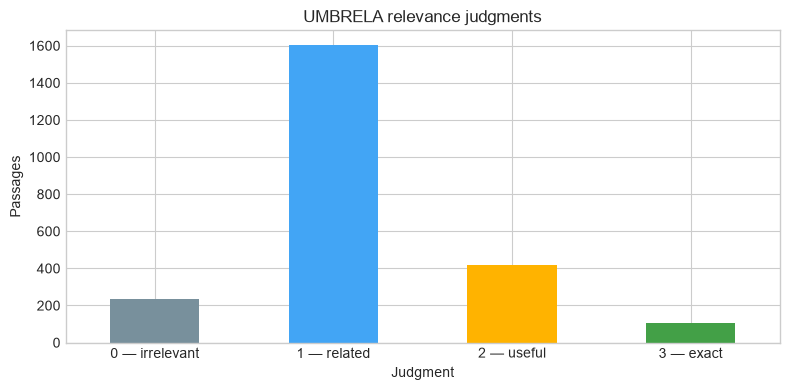

In [10]:
valid = df[df.status.eq('completed')].copy()
valid['judgment'] = pd.to_numeric(valid.judgment, errors='coerce')
valid = valid[valid.judgment.isin([0, 1, 2, 3])]
score_counts = valid.judgment.value_counts().reindex(range(4), fill_value=0)
score_rates = (score_counts / score_counts.sum()).rename('rate')
display(pd.concat([score_counts.rename('count'), score_rates], axis=1))
ax = score_counts.plot.bar(figsize=(8, 4), color=['#78909c', '#42a5f5', '#ffb300', '#43a047'])
ax.set(title='UMBRELA relevance judgments', xlabel='Judgment', ylabel='Passages')
ax.set_xticklabels(['0 — irrelevant', '1 — related', '2 — useful', '3 — exact'], rotation=0)
plt.tight_layout(); plt.show()

## Results by run split

,score_0,score_1,score_2,score_3,total,mean_score
run_id,,,,,,
aus-agent-test-v2,83,713,207,50,1053,1.212726
aus-agent-test-full,71,439,134,38,682,1.203812
aus-agent-dev-full,64,331,49,8,452,1.002212
aus-agent-creative-check,15,104,13,2,134,1.014925
viewer-20260717T020657,0,2,5,0,7,1.714286
aus-agent-math-check,0,3,3,0,6,1.500000
aus-agent-discovery-check,0,3,1,2,6,1.833333
viewer-20260717T020901,0,4,0,2,6,1.666667
aus-agent-protocol-check-v5,1,0,3,1,5,1.800000


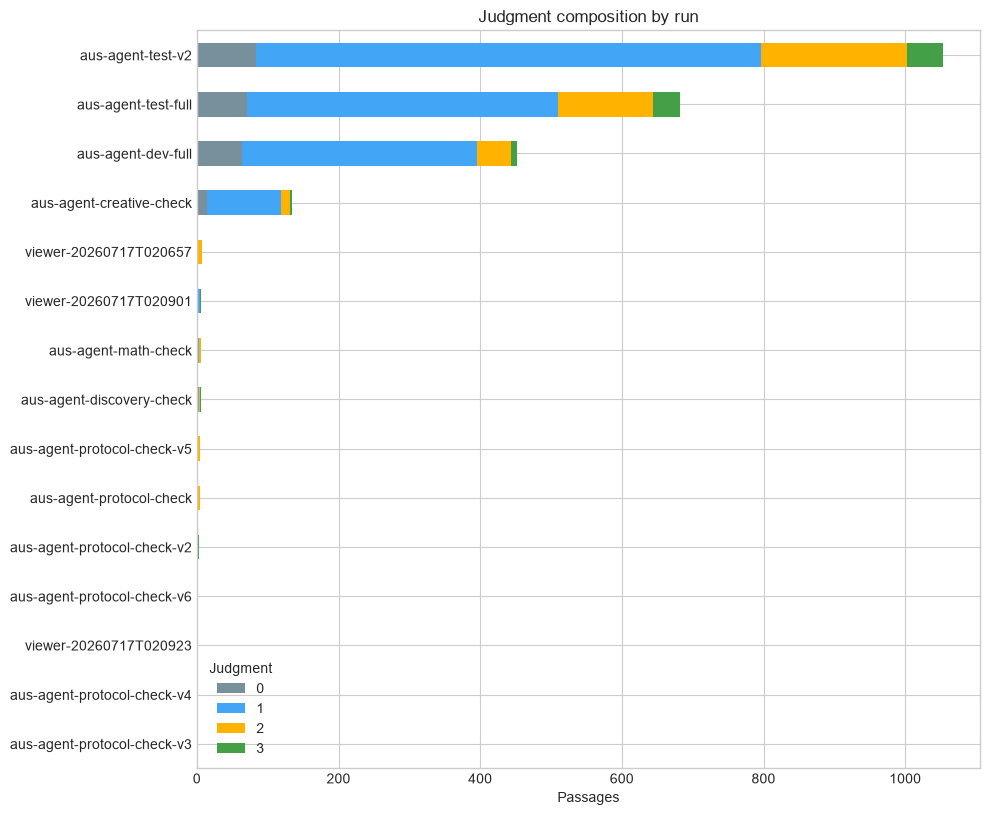

In [11]:
valid['run_id'] = valid.qid.str.split('::', n=1).str[0]
by_run = (valid.groupby(['run_id', 'judgment']).size().unstack(fill_value=0)
          .reindex(columns=range(4), fill_value=0))
by_run.columns = [f'score_{int(c)}' for c in by_run.columns]
by_run['total'] = by_run.sum(axis=1)
by_run['mean_score'] = valid.groupby('run_id').judgment.mean()
display(by_run.sort_values('total', ascending=False))
plot_data = by_run.loc[by_run.total.sort_values().index, [f'score_{i}' for i in range(4)]]
ax = plot_data.plot.barh(stacked=True, figsize=(10, max(4, len(plot_data) * 0.55)),
                         color=['#78909c', '#42a5f5', '#ffb300', '#43a047'])
ax.set(title='Judgment composition by run', xlabel='Passages', ylabel='')
ax.legend(['0', '1', '2', '3'], title='Judgment')
plt.tight_layout(); plt.show()

## Query-level relevance profile

,run_id,qid,passages,mean_score,relevant_at_2,exact,query,relevant_at_2_rate
43,aus-agent-protocol-check-v3,aus-agent-protocol-check-v3::adhoc,1,3.000000,1,1,Who's the president of the United States?,1.0
46,aus-agent-protocol-check-v6,aus-agent-protocol-check-v6::adhoc,1,3.000000,1,1,Who's the president of the United States?,1.0
175,viewer-20260717T020923,viewer-20260717T020923::adhoc,1,3.000000,1,1,when is sigir 2023?,1.0
65,aus-agent-test-full,aus-agent-test-full::rag2026-25,9,2.555556,9,5,The 1956 Suez Crisis marked a pivotal moment in the reshaping of global power after World War II. In what ways did the crisis reveal the limits of European ...,1.0
44,aus-agent-protocol-check-v4,aus-agent-protocol-check-v4::adhoc,1,2.000000,1,0,Who's the president of the United States?,1.0
...,...,...,...,...,...,...,...,...
22,aus-agent-dev-full,aus-agent-dev-full::6847465956a0f6376a6053a0,24,0.583333,0,0,Write a technical proposal for a distributed audio streaming system. The system should include an audio streaming platform and a live chat feature. This app...,0.0
77,aus-agent-test-full,aus-agent-test-full::rag2026-36,22,0.545455,0,0,Design a cross-platform anti-cheat system for a competitive first-person shooter video game that could potentially handle up to 1 million concurrent users a...,0.0
123,aus-agent-test-v2,aus-agent-test-v2::rag2026-36,12,0.416667,0,0,Design a cross-platform anti-cheat system for a competitive first-person shooter video game that could potentially handle up to 1 million concurrent users a...,0.0
31,aus-agent-dev-full,aus-agent-dev-full::6847465956a0f6376a605476,10,0.400000,0,0,"Imagine the following alternate history timeline: 1. Operation Barbarossa was anticipated by Joseph Stalin, causing the Soviet army to be well-prepared for ...",0.0


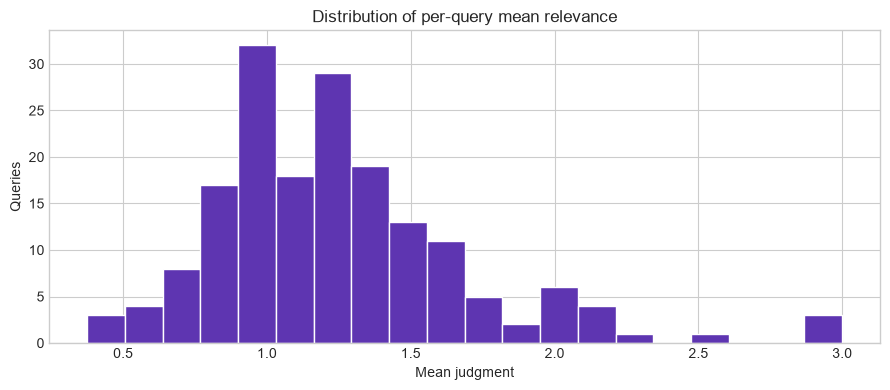

In [12]:
query_summary = (valid.groupby(['run_id', 'qid'], as_index=False)
    .agg(passages=('judgment', 'size'), mean_score=('judgment', 'mean'),
         relevant_at_2=('judgment', lambda s: int((s >= 2).sum())),
         exact=('judgment', lambda s: int((s == 3).sum())), query=('query', 'first')))
query_summary['relevant_at_2_rate'] = query_summary.relevant_at_2 / query_summary.passages
display(query_summary.sort_values(['relevant_at_2_rate', 'mean_score'], ascending=[False, False]))
ax = query_summary.mean_score.hist(bins=20, figsize=(9, 4), color='#5e35b1', edgecolor='white')
ax.set(title='Distribution of per-query mean relevance', xlabel='Mean judgment', ylabel='Queries')
plt.tight_layout(); plt.show()

## Passage inspector

Change the filters and rerun this cell to inspect individual judgments.

In [13]:
RUN = None       # e.g. 'aus-agent-dev-full'
QID = None       # paste an exact qid
SCORES = [2, 3]  # any subset of [0, 1, 2, 3]
LIMIT = 100

review = valid[valid.judgment.isin(SCORES)].copy()
if RUN: review = review[review.run_id.eq(RUN)]
if QID: review = review[review.qid.eq(QID)]
columns = [c for c in ['run_id', 'qid', 'docid', 'judgment', 'query', 'passage', 'prediction'] if c in review]
display(review[columns].head(LIMIT).reset_index(drop=True))

,run_id,qid,docid,judgment,query,passage,prediction
0,aus-agent-test-full,aus-agent-test-full::rag2026-0,shard_00122_5199,2,I’m on a hospital nursing DEI council that has to recommend a three-year plan with limited money. Our chief nursing officer wants something that helps recru...,"The lack of diversity is a problem in nursing. Currently, 80% of registered nurses (RNs) identify as white, compared to 72% of the overall U.S. population, ...",##final score: 2
1,aus-agent-dev-full,aus-agent-dev-full::683a58c9a7e7fe4e7695846f,shard_02627_52938,2,"Write a blog post contrasting Euclidean geometry used in high school math competitions such as the AMC, AIME, or Olympiads to geometry taught in the standar...",Stewart's Theorem\nA theorem in planar Euclidean geometry that gives an algebraic relationship between sides of a triangle and segments of sides when cevian...,##final score: 2
2,aus-agent-test-full,aus-agent-test-full::rag2026-0,shard_05600_33708,2,I’m on a hospital nursing DEI council that has to recommend a three-year plan with limited money. Our chief nursing officer wants something that helps recru...,"The New Face of Nursing\nBy Chris Williams\nShe sits alone in her hospital bed, thoughts racing through her mind. The staff is doing the best they can despi...",##final score: 2
3,aus-agent-test-full,aus-agent-test-full::rag2026-1,shard_01365_80575,2,"My mother is 72 and my father died suddenly six weeks ago. She keeps saying grief is just emotional, but she has had chest tightness, poor sleep, little app...","It is possible to die of a broken heart, say scientists\nThe grief of losing a loved one doubles the risk of a heart attack, according to a British-based st...",##final score: 2
4,aus-agent-test-full,aus-agent-test-full::rag2026-0,shard_00520_38943,2,I’m on a hospital nursing DEI council that has to recommend a three-year plan with limited money. Our chief nursing officer wants something that helps recru...,The Future of Nursing Must Be Diverse\n\nInclusion has to be an intentional part of the plan as strategies to diversify the nursing field are adopted.\n\nSh...,##final score: 2
...,...,...,...,...,...,...,...
95,aus-agent-dev-full,aus-agent-dev-full::6847465956a0f6376a60542a,shard_06109_52630,2,"I am a software engineer at a small startup, trying to scale our product to around 1M users / day from around the world. The service is a social media app s...","your application does a read that, from the user's perspective, depends on a\nwrite that happened earlier. For example, a user clicks ""Add to cart"", which\n...",##final score: 2
96,aus-agent-dev-full,aus-agent-dev-full::6847465956a0f6376a60542a,shard_04535_538,2,"I am a software engineer at a small startup, trying to scale our product to around 1M users / day from around the world. The service is a social media app s...",Database sharding is the process of splitting up a database across multiple machines to improve the scalability of an application. The justification for dat...,##final score: 2
97,aus-agent-dev-full,aus-agent-dev-full::6847465956a0f6376a60542a,shard_02046_26492,2,"I am a software engineer at a small startup, trying to scale our product to around 1M users / day from around the world. The service is a social media app s...",Kafka offers superior scalability and performance compared to traditional REST APIs used for communication between service data processing. Using publish-su...,##final score: 2
98,aus-agent-dev-full,aus-agent-dev-full::6847465956a0f6376a60542a,shard_01866_16499,2,"I am a software engineer at a small startup, trying to scale our product to around 1M users / day from around the world. The service is a social media app s...",Scaling Memcached at Facebook\nIn a cluster:\nReduce latency\nProblem: Items are distributed across the memcached servers through consistent hashing. Thus w...,##final score: 2


## Failed and suspicious rows

In [14]:
failed = df[df.status.ne('completed')].copy()
display(failed[[c for c in ['task_id', 'qid', 'docid', 'result_status', 'error'] if c in failed]].reset_index(drop=True))
if 'prediction' in df:
    suspicious = df[df.status.eq('completed') & ~df.prediction.fillna('').str.contains(r'##final score:\s*[0-3]', regex=True)]
    print(f'Completed rows without the expected score marker: {len(suspicious):,}')
    display(suspicious[[c for c in ['task_id', 'qid', 'docid', 'judgment', 'prediction'] if c in suspicious]].head(100))

,task_id,qid,docid,result_status,error


Completed rows without the expected score marker: 2


,task_id,qid,docid,judgment,prediction
741,aus-agent-dev-full::6847465956a0f6376a60547e:15,aus-agent-dev-full::6847465956a0f6376a60547e,shard_02295_23124,2,##final score: M=2\n##final score: T=3\n##final score: O=2
1396,aus-agent-test-v2::rag2026-17:3,aus-agent-test-v2::rag2026-17,shard_00776_61945,1,##M: 1\n##T: 3\n##O: 1
